# Bulk Proteomics Basic Workflow

**Purpose**: Basic pipeline for bulk proteomics data analysis

**Dataset**: CPTAC Colon Cancer (pre-processed data; this notebook focuses on understanding concepts and methods at each step)

**Table of Contents**:
1. Understanding Data Structure
2. Quality Control
3. Missing Value Handling (Imputation)
4. Normalization Overview
5. Differential Expression Analysis (DEP)
6. Functional Enrichment (GO/KEGG/GSEA)
7. Unsupervised Clustering
8. Multi-omics Integration Basics

---

## 0. Environment Setup

In [61]:
# Install required packages
# !pip install cptac gseapy matplotlib seaborn scipy scikit-learn statsmodels adjustText

In [62]:
import cptac
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("Setup complete!")

Setup complete!


In [63]:
# Load dataset
colon = cptac.Coad()

---
## 1. Understanding Data Structure

### What is MS-based proteomics data?

Mass spectrometry (MS)-based proteomics involves the following steps:

```
Tissue sample → Protein extraction → Trypsin digestion (into peptides)
→ LC-MS/MS (mass spectrometry) → Peptide identification → Protein quantification
```

**CPTAC data characteristics**:
- Relative quantification based on TMT (Tandem Mass Tag)
- Values are log2 ratios relative to a pooled reference → positive values are higher than reference, negative values are lower
- Values near 0 represent average expression levels

**Note on other acquisition methods**:
- DIA (Data-Independent Acquisition)-based data uses a similar analytical workflow but produces different quantification scales
- Quantile-normalized intensity values differ in scale from TMT ratios
- Both approaches are relative quantification methods

In [64]:
# Check available data types
print("=== Available data types ===")
colon.get_data_list()
colon.list_data_sources()

=== Available data types ===


,Data type,Available sources
0,CNV,"[bcm, washu]"
1,miRNA,[bcm]
2,phosphoproteomics,"[bcm, umich]"
3,proteomics,"[bcm, umich]"
4,transcriptomics,"[bcm, broad, washu]"
5,ancestry_prediction,[harmonized]
6,somatic_mutation,"[harmonized, washu]"
7,clinical,[mssm]
8,follow-up,[mssm]
9,medical_history,[mssm]


In [65]:
# Load and inspect proteomics data
proteomics = colon.get_proteomics(source='umich')

print(f"Shape: {proteomics.shape}\n")
print(f"Index (samples): {proteomics.index[:5].tolist()}\n")
print(f"Column type: {type(proteomics.columns)}\n")

# Handle MultiIndex columns
if isinstance(proteomics.columns, pd.MultiIndex):
    print(f"Column levels: {proteomics.columns.names}")
    print(f"Level 0 (gene names) sample: {proteomics.columns.get_level_values(0)[:5].tolist()}")
    # Flatten to gene name level only
    prot = proteomics.copy()
    prot.columns = prot.columns.get_level_values(0)  # Extract gene names only
    prot = prot.T.groupby(level=0).mean().T          # Average duplicate gene names
else:
    prot = proteomics.copy()

print(f"\nProcessed shape: {prot.shape} (samples × proteins)")
print(f"Value range: [{prot.min().min():.2f}, {prot.max().max():.2f}]")
print(f"\nFirst 5×5:")
prot.iloc[:5, :5]

Shape: (197, 9457)

Index (samples): ['01CO005', '01CO006', '01CO008', '01CO013', '01CO014']

Column type: <class 'pandas.MultiIndex'>

Column levels: ['Name', 'Database_ID']
Level 0 (gene names) sample: ['ARF5', 'M6PR', 'ESRRA', 'FKBP4', 'NDUFAF7']

Processed shape: (197, 9153) (samples × proteins)
Value range: [-6.74, 6.83]

First 5×5:


Name,A1BG,A1CF,A2M,AAAS,AACS
Patient_ID,,,,,
01CO005,-0.958056,0.407197,-0.392240,-0.171658,0.171299
01CO006,-0.921917,-0.505941,-0.258659,0.103594,0.016672
01CO008,-0.941201,-0.113859,-1.731292,0.195256,-0.182270
01CO013,-1.465025,0.201009,-0.303796,0.542174,0.183197
01CO014,-0.408567,-0.067079,-0.518531,0.218479,0.310743


In [66]:
# Clinical data
clinical = colon.get_clinical(source='mssm')
print(f"Clinical shape: {clinical.shape}")
print(f"\nColumns:")
for col in clinical.columns:
    print(f"  - {col}: {clinical[col].nunique()} unique values")

Clinical shape: (109, 124)

Columns:
  - tumor_code: 1 unique values
  - discovery_study: 1 unique values
  - type_of_analyzed_samples: Name
type_of_analyzed_samples    0
type_of_analyzed_samples    0
dtype: int64 unique values
  - confirmatory_study: 0 unique values
  - type_of_analyzed_samples: Name
type_of_analyzed_samples    0
type_of_analyzed_samples    0
dtype: int64 unique values
  - age: 43 unique values
  - sex: 2 unique values
  - race: 5 unique values
  - ethnicity: 3 unique values
  - ethnicity_race_ancestry_identified: 0 unique values
  - Inferred ancestry: 4 unique values
  - collection_in_us: 0 unique values
  - participant_country: 0 unique values
  - maternal_grandmother_country: 0 unique values
  - maternal_grandfather_country: 0 unique values
  - paternal_grandmother_country: 0 unique values
  - paternal_grandfather_country: 0 unique values
  - deaf_or_difficulty_hearing: 0 unique values
  - blind_or_difficulty_seeing: 0 unique values
  - difficulty_concentrating_rem

---
## 2. Quality Control (QC)

The goal of QC is to identify problematic samples or proteins and address them before analysis.

Key checkpoints:
1. Missing value patterns
2. Overall expression distribution
3. Sample-to-sample correlation
4. Outlier detection (PCA)
5. Tumor vs Normal separation

### 2.1 Missing Value Analysis

Missing values are very common in MS proteomics. There are two main causes:
- **MCAR (Missing Completely At Random)**: Random loss due to technical reasons
- **MNAR (Missing Not At Random)**: Below detection limit due to low expression → more common

The appropriate imputation strategy depends on the type of missingness.

Total values: 1,803,141
Missing values: 432,566 (24.0%)


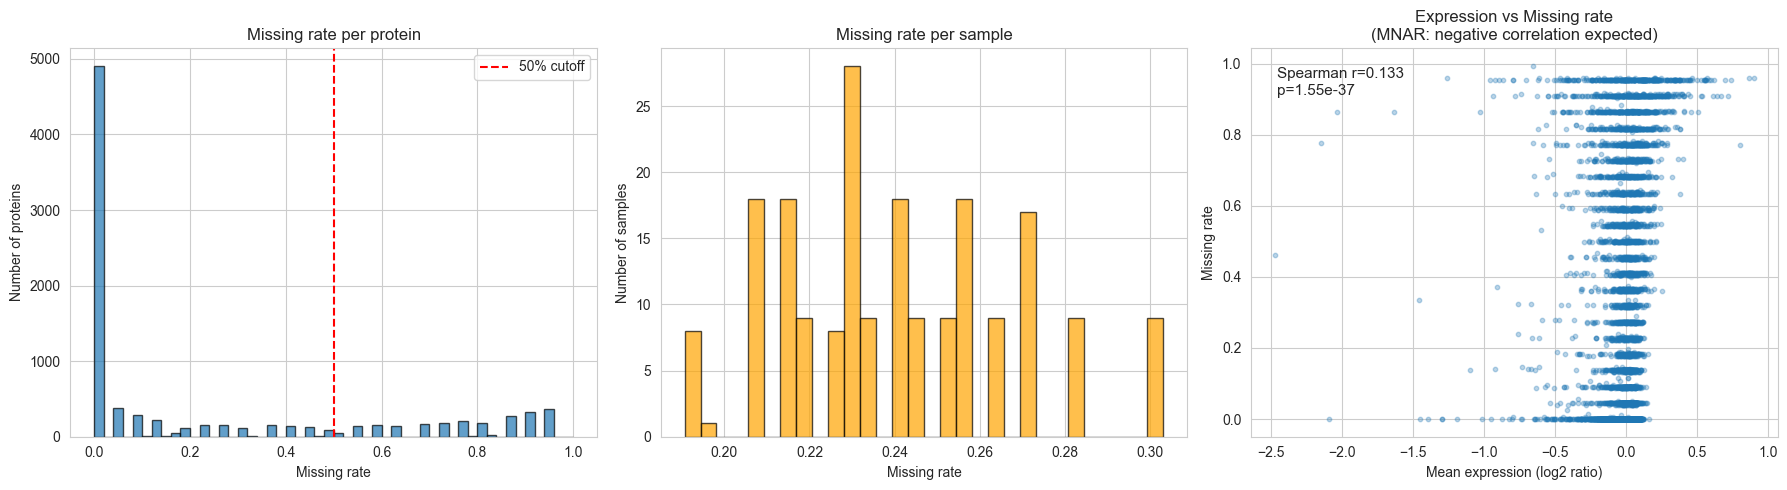


Proteins with <50% missing: 6910/9153
Proteins with 0% missing: 4892/9153


In [67]:
# Overall missing value summary
total_values = prot.size
missing_values = prot.isnull().sum().sum()
print(f"Total values: {total_values:,}")
print(f"Missing values: {missing_values:,} ({missing_values/total_values:.1%})")

# Missing rate per protein and per sample
missing_per_protein = prot.isnull().mean()
missing_per_sample = prot.isnull().mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Missing rate distribution per protein
axes[0].hist(missing_per_protein, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Missing rate')
axes[0].set_ylabel('Number of proteins')
axes[0].set_title('Missing rate per protein')
axes[0].axvline(0.5, color='red', linestyle='--', label='50% cutoff')
axes[0].legend()

# Missing rate distribution per sample
axes[1].hist(missing_per_sample, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Missing rate')
axes[1].set_ylabel('Number of samples')
axes[1].set_title('Missing rate per sample')

# Check whether missing values are associated with expression level (MNAR check)
mean_expr = prot.mean()
axes[2].scatter(mean_expr, missing_per_protein, alpha=0.3, s=10)
axes[2].set_xlabel('Mean expression (log2 ratio)')
axes[2].set_ylabel('Missing rate')
axes[2].set_title('Expression vs Missing rate\n(MNAR: negative correlation expected)')

r, p = stats.spearmanr(mean_expr.dropna(), missing_per_protein[mean_expr.dropna().index])
axes[2].annotate(f'Spearman r={r:.3f}\np={p:.2e}', xy=(0.05, 0.95),
                 xycoords='axes fraction', fontsize=11, va='top')

plt.tight_layout()
plt.show()

print(f"\nProteins with <50% missing: {(missing_per_protein < 0.5).sum()}/{len(missing_per_protein)}")
print(f"Proteins with 0% missing: {(missing_per_protein == 0).sum()}/{len(missing_per_protein)}")

### 2.2 Expression Distribution and Normalization Status

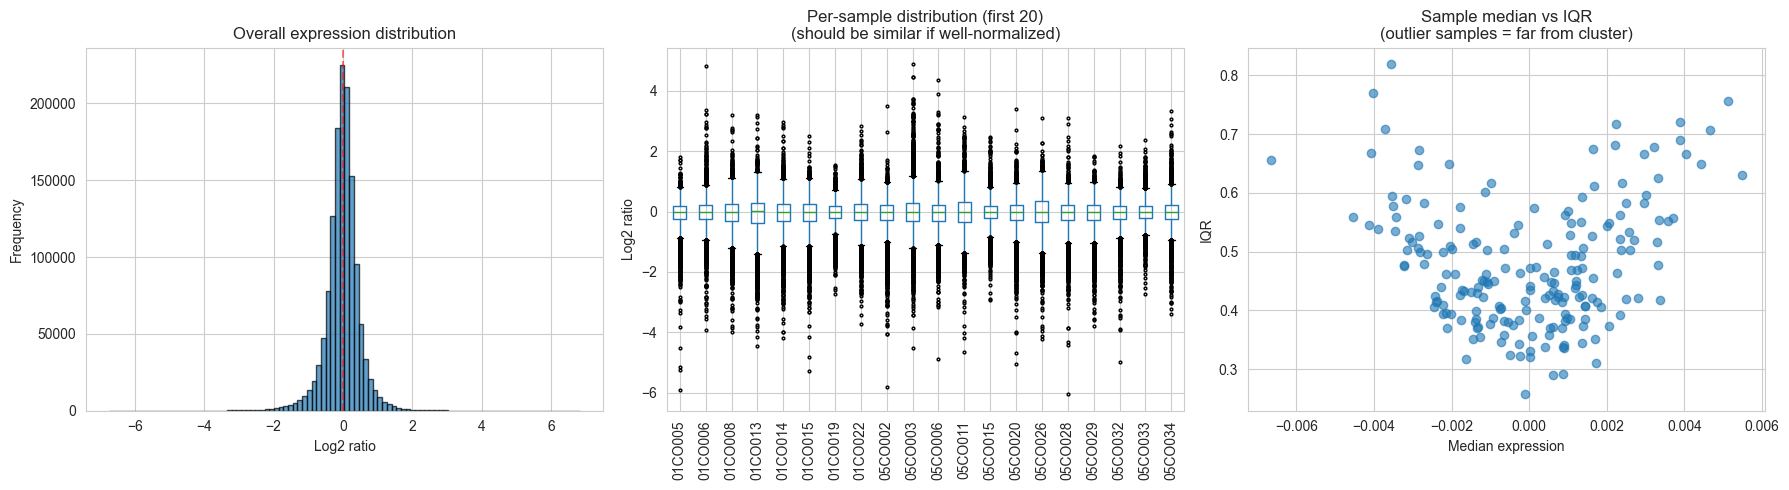

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall value distribution
all_vals = prot.values.flatten()
all_vals = all_vals[~np.isnan(all_vals)]
axes[0].hist(all_vals, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Log2 ratio')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall expression distribution')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

# Per-sample boxplot (first 20 samples)
prot.iloc[:20, :].T.boxplot(ax=axes[1], rot=90, flierprops=dict(markersize=2))
axes[1].set_ylabel('Log2 ratio')
axes[1].set_title('Per-sample distribution (first 20)\n(should be similar if well-normalized)')

# Per-sample median and IQR
sample_medians = prot.median(axis=1)
sample_iqrs = prot.quantile(0.75, axis=1) - prot.quantile(0.25, axis=1)
axes[2].scatter(sample_medians, sample_iqrs, alpha=0.6)
axes[2].set_xlabel('Median expression')
axes[2].set_ylabel('IQR')
axes[2].set_title('Sample median vs IQR\n(outlier samples = far from cluster)')

plt.tight_layout()
plt.show()

### 2.3 Sample Correlation and Outlier Detection

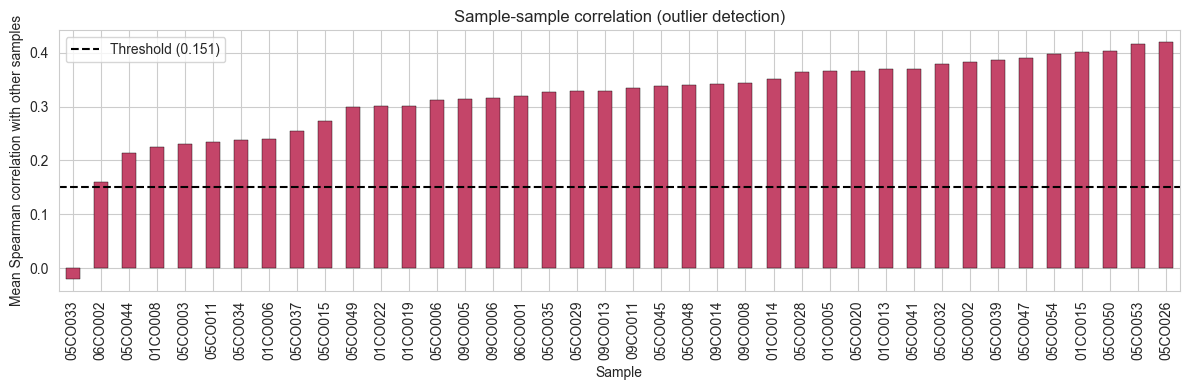

Threshold (mean - 2*std): 0.151
Potential outlier samples: 1
Patient_ID
05CO033   -0.020497
dtype: float64


In [69]:
# Sample-to-sample correlation — outlier sample detection
subset = prot.iloc[:40, :]
corr_matrix = subset.T.corr(method='spearman')

mean_corr = corr_matrix.mean()
threshold = mean_corr.mean() - 2 * mean_corr.std()
outliers = mean_corr[mean_corr < threshold]

plt.figure(figsize=(12, 4))
mean_corr.sort_values().plot(kind='bar', color='#C44569', edgecolor='black', linewidth=0.3)
plt.axhline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.3f})')
plt.ylabel('Mean Spearman correlation with other samples')
plt.xlabel('Sample')
plt.title('Sample-sample correlation (outlier detection)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Threshold (mean - 2*std): {threshold:.3f}")
print(f"Potential outlier samples: {len(outliers)}")
if len(outliers) > 0:
    print(outliers)

Columns after removing all-NaN: 9152 / 9153


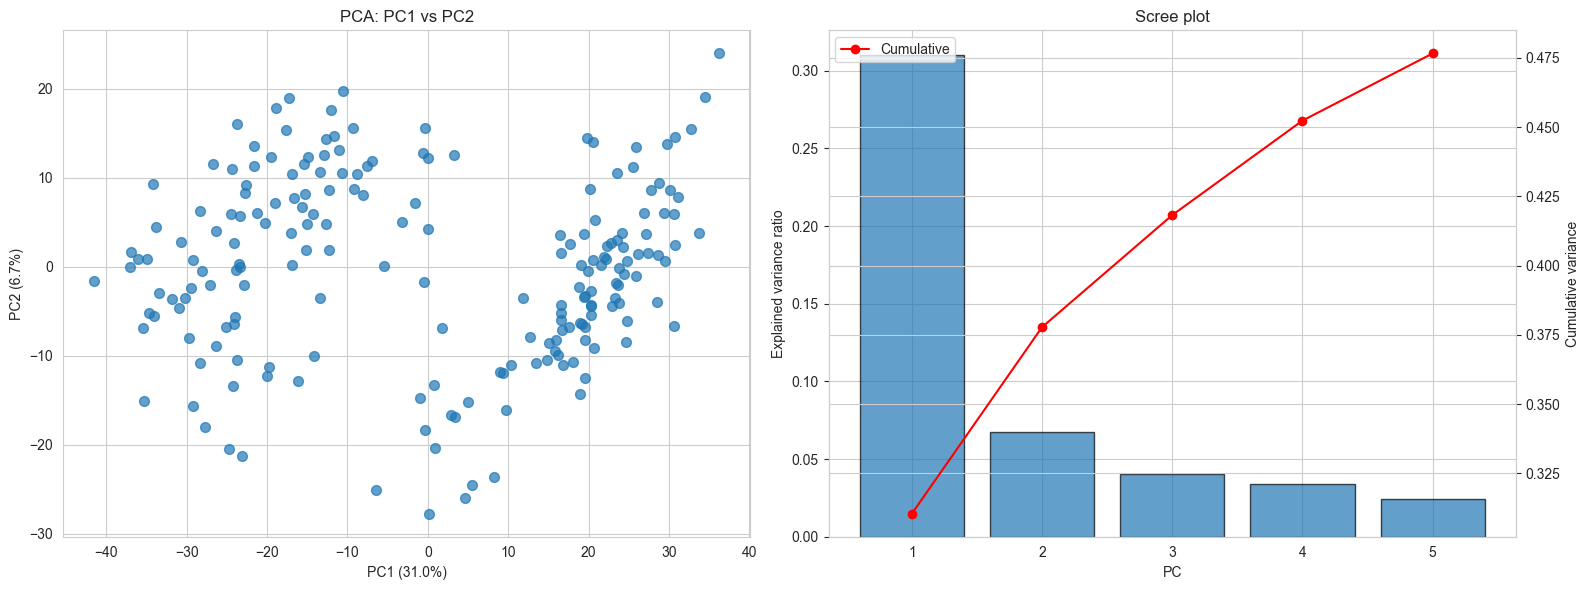

PC1-5 cumulative variance: 47.7%


In [70]:
# PCA for overall structure + outlier check

# 1) Remove all-NaN columns (SimpleImputer cannot handle them)
prot_filtered = prot.dropna(axis=1, how="all")
print(f"Columns after removing all-NaN: {prot_filtered.shape[1]} / {prot.shape[1]}")

# 2) Temporarily fill missing values with median
imputer = SimpleImputer(strategy="median")
prot_imputed = pd.DataFrame(
    imputer.fit_transform(prot_filtered),
    index=prot_filtered.index, columns=prot_filtered.columns
)

# 3) Set n_components safely as min(n_samples, n_features, 5)
n_comp = min(5, prot_imputed.shape[0], prot_imputed.shape[1])
pca = PCA(n_components=n_comp)
pca_result = pca.fit_transform(prot_imputed)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 vs PC2
axes[0].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.7, s=50)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("PCA: PC1 vs PC2")

# Scree plot
axes[1].bar(range(1, n_comp + 1), pca.explained_variance_ratio_, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("PC")
axes[1].set_ylabel("Explained variance ratio")
axes[1].set_title("Scree plot")
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax2 = axes[1].twinx()
ax2.plot(range(1, n_comp + 1), cumvar, "ro-", label="Cumulative")
ax2.set_ylabel("Cumulative variance")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"PC1-{n_comp} cumulative variance: {cumvar[-1]:.1%}")

---
## 3. Missing Value Handling (Imputation)

Imputation is critically important in proteomics. The choice of method can substantially affect downstream analysis results.

### Key strategies:
| Method | Assumption | Pros | Cons | When to use |
|--------|-----------|------|------|-------------|
| Median | MCAR | Simple, fast | Ignores MNAR | Quick exploration |
| KNN | MCAR | Captures correlation structure | Slow, ignores MNAR | When correlation structure exists |
| MinProb | MNAR | Reflects low expression | May underestimate | When MNAR is suspected |
| Removal | — | No bias | Data loss | When missingness is high |

**Practical recommendation**: Remove proteins with >50% missing values; for the remainder, choose based on analysis goal

In [71]:
# Step 1: Filter proteins with high missing rate
max_missing = 0.5
prot_filtered = prot.loc[:, prot.isnull().mean() < max_missing]
print(f"Proteins before filtering: {prot.shape[1]}")
print(f"Proteins after filtering (<{max_missing:.0%} missing): {prot_filtered.shape[1]}")
print(f"Removed: {prot.shape[1] - prot_filtered.shape[1]}")

Proteins before filtering: 9153
Proteins after filtering (<50% missing): 6910
Removed: 2243


In [72]:
# Compare 3 imputation methods

# 1) Median imputation
imp_median = SimpleImputer(strategy='median')
prot_median = pd.DataFrame(
    imp_median.fit_transform(prot_filtered),
    index=prot_filtered.index, columns=prot_filtered.columns
)

# 2) KNN imputation
from sklearn.impute import KNNImputer
imp_knn = KNNImputer(n_neighbors=5)
prot_knn = pd.DataFrame(
    imp_knn.fit_transform(prot_filtered),
    index=prot_filtered.index, columns=prot_filtered.columns
)

# 3) MinProb imputation (MNAR assumption: sample from the lower tail of the distribution)
def minprob_impute(df, q=0.01):
    """Impute missing values by random sampling from the lower quantile of each protein"""
    result = df.copy()
    for col in result.columns:
        missing_mask = result[col].isnull()
        if missing_mask.any():
            observed = result[col].dropna()
            low_val = observed.quantile(q)
            sd = observed.std() * 0.3  # narrow variance
            n_missing = missing_mask.sum()
            imputed = np.random.normal(low_val, sd, n_missing)
            result.loc[missing_mask, col] = imputed
    return result

np.random.seed(42)
prot_minprob = minprob_impute(prot_filtered)

print("Imputation complete for all 3 methods.")

Imputation complete for all 3 methods.


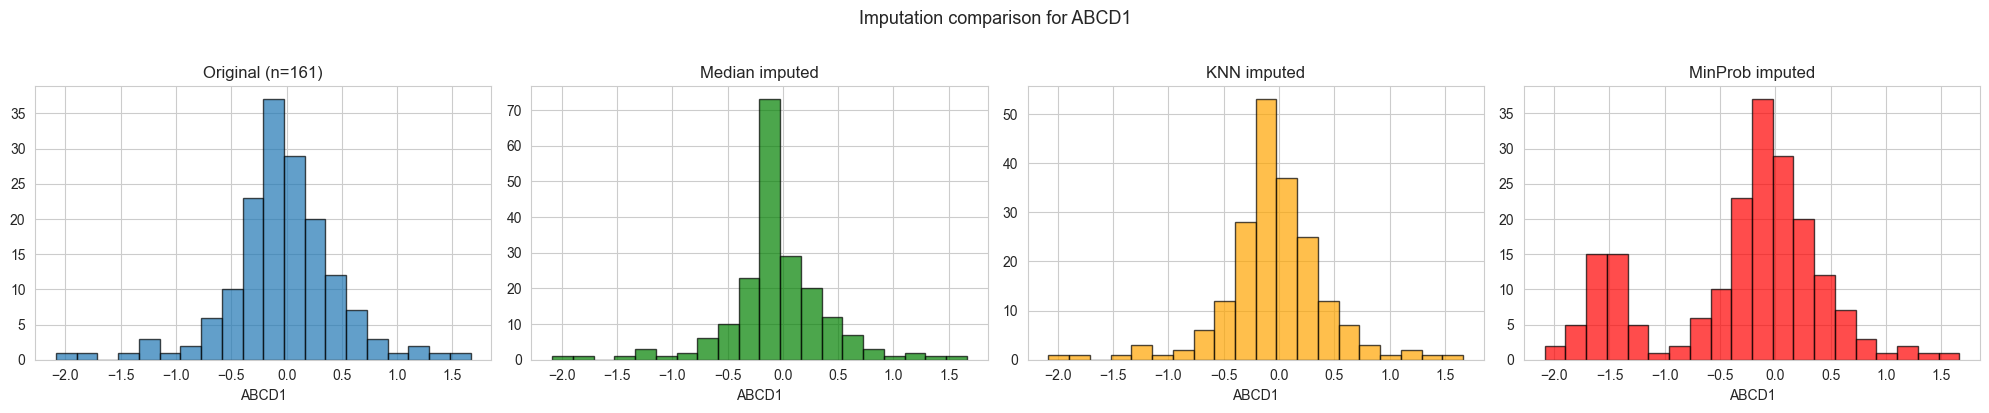


Final clean data: (197, 6910)


In [73]:
# Compare distribution across imputation methods
# Select one protein with notable missingness as a test case
test_protein = prot_filtered.columns[prot_filtered.isnull().mean() > 0.1][0]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].hist(prot_filtered[test_protein].dropna(), bins=20, alpha=0.7, edgecolor='black')
axes[0].set_title(f'Original (n={prot_filtered[test_protein].notna().sum()})')

axes[1].hist(prot_median[test_protein], bins=20, alpha=0.7, edgecolor='black', color='green')
axes[1].set_title('Median imputed')

axes[2].hist(prot_knn[test_protein], bins=20, alpha=0.7, edgecolor='black', color='orange')
axes[2].set_title('KNN imputed')

axes[3].hist(prot_minprob[test_protein], bins=20, alpha=0.7, edgecolor='black', color='red')
axes[3].set_title('MinProb imputed')

for ax in axes:
    ax.set_xlabel(test_protein)

plt.suptitle(f'Imputation comparison for {test_protein}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Use KNN imputation for subsequent analyses (common choice)
prot_clean = prot_knn.copy()
print(f"\nFinal clean data: {prot_clean.shape}")

---
## 4. Normalization

CPTAC data is already normalized, but understanding the concepts is essential.

### Why normalize?
- Remove technical variation between samples (loading amount differences, instrument drift, etc.)
- Goal: retain only biological differences

### Key methods:
- **Median centering**: Shifts each sample's median to 0 → the most basic approach
- **Quantile normalization**: Forces identical distributions across samples → the strongest normalization
- **Median of ratios (DESeq2 style)**: Corrects for differences relative to a reference sample

Current sample medians (should be ~0):
count    197.000000
mean      -0.001205
std        0.005431
min       -0.022440
25%       -0.005100
50%       -0.001284
75%        0.002639
max        0.014682
dtype: float64


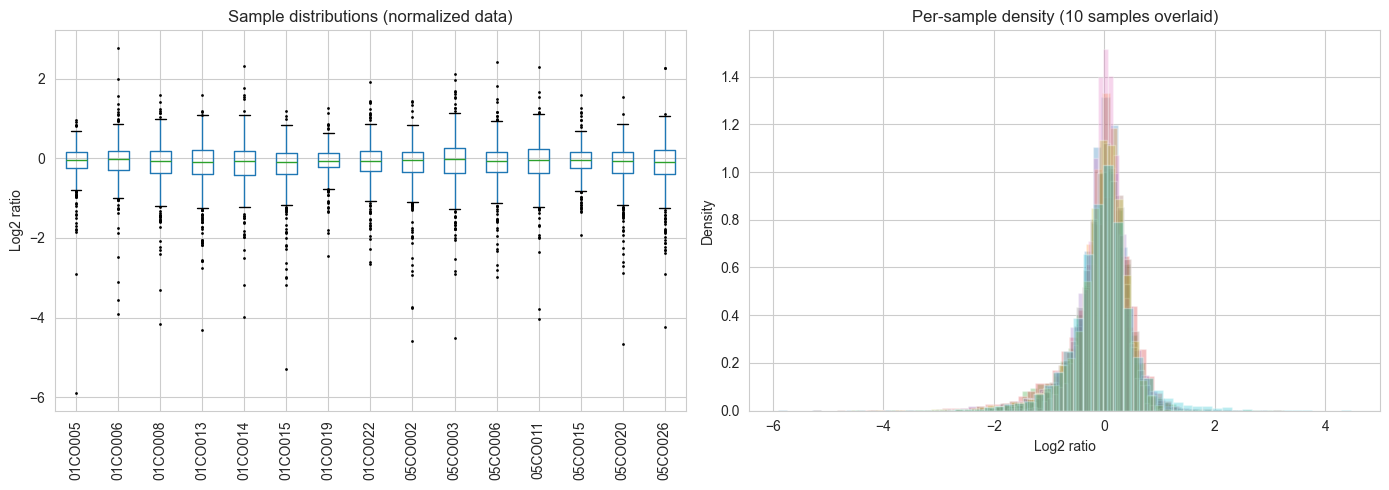

In [74]:
# Normalization comparison (demo: median centering)
# CPTAC data is already normalized. This cell is for conceptual understanding.

# Current state (already normalized)
print("Current sample medians (should be ~0):")
print(prot_clean.median(axis=1).describe())

# If data were not normalized, you would apply:
def median_center(df):
    """Shift each sample's median to 0"""
    return df.sub(df.median(axis=1), axis=0)

def quantile_normalize(df):
    """Quantile normalization: make distributions identical across samples"""
    rank_mean = df.stack().groupby(
        df.rank(method='first').stack().astype(int)
    ).mean()
    return df.rank(method='min').stack().astype(int).map(rank_mean).unstack()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-sample distribution (boxplot, first 15 samples)
prot_clean.iloc[:15, :500].T.boxplot(ax=axes[0], rot=90,
    flierprops=dict(markersize=1))
axes[0].set_title('Sample distributions (normalized data)')
axes[0].set_ylabel('Log2 ratio')

# Per-sample density
for i in range(min(10, prot_clean.shape[0])):
    axes[1].hist(prot_clean.iloc[i, :], bins=50, alpha=0.3, density=True)
axes[1].set_xlabel('Log2 ratio')
axes[1].set_ylabel('Density')
axes[1].set_title('Per-sample density (10 samples overlaid)')

plt.tight_layout()
plt.show()

---
## 5. Differential Expression Analysis (DEP)

Identifying proteins with significantly different expression levels between two groups.

This is conceptually equivalent to DEG (Differentially Expressed Genes) in RNA-seq,
but in proteomics it is referred to as DEP (Differentially Expressed Proteins).

**Here we compare Tumor vs Normal samples.**

In [75]:
# Separate tumor vs normal samples
# In CPTAC, normal samples typically have a '.N' suffix
sample_type = pd.Series('Tumor', index=prot_clean.index)
normal_mask = prot_clean.index.str.contains('.N', regex=False) | prot_clean.index.str.contains('Normal')
sample_type[normal_mask] = 'Normal'

print(f"Tumor: {(sample_type == 'Tumor').sum()}")
print(f"Normal: {(sample_type == 'Normal').sum()}")

# If separation fails, check clinical data
if (sample_type == 'Normal').sum() == 0:
    print("\nNo normal samples found by index pattern.")
    print("Checking clinical data...")
    print(clinical.columns.tolist())

Tumor: 97
Normal: 100


In [76]:
# DEP analysis (Welch's t-test + fold change)

def run_dep(data, group_labels, group1='Tumor', group2='Normal'):
    """
    Differential Expression analysis for Proteins
    Returns: DataFrame with log2FC, p-value, FDR
    """
    g1_data = data[group_labels == group1]
    g2_data = data[group_labels == group2]
    
    results = []
    for protein in data.columns:
        g1 = g1_data[protein].dropna()
        g2 = g2_data[protein].dropna()
        
        if len(g1) < 3 or len(g2) < 3:
            continue
        
        log2fc = g1.mean() - g2.mean()  # Already in log2 scale, so difference = log2FC
        stat, pval = stats.ttest_ind(g1, g2, equal_var=False)
        
        results.append({
            'protein': protein,
            'log2FC': log2fc,
            'p_value': pval,
            'mean_g1': g1.mean(),
            'mean_g2': g2.mean()
        })
    
    df = pd.DataFrame(results)
    
    # BH correction
    from statsmodels.stats.multitest import multipletests
    df['fdr'] = multipletests(df['p_value'], method='fdr_bh')[1]
    df['-log10p'] = -np.log10(df['p_value'])
    
    return df.sort_values('p_value')

# Run DEP (only if normal samples are available)
if (sample_type == 'Normal').sum() >= 3:
    dep_results = run_dep(prot_clean, sample_type)
    print(f"DEP results: {len(dep_results)} proteins tested")
    print(f"Significant (FDR<0.05): {(dep_results['fdr'] < 0.05).sum()}")
    print(f"  - Upregulated (FC>1.5): {((dep_results['fdr']<0.05) & (dep_results['log2FC']>np.log2(1.5))).sum()}")
    print(f"  - Downregulated (FC<-1.5): {((dep_results['fdr']<0.05) & (dep_results['log2FC']<-np.log2(1.5))).sum()}")
    print(f"\nTop 10 DEPs:")
    print(dep_results.head(10)[['protein','log2FC','p_value','fdr']].to_string(index=False))
else:
    print("Not enough normal samples. Skipping Tumor vs Normal DEP.")
    print("Alternative: compare by stage, MSI status, etc.")
    dep_results = None

DEP results: 6910 proteins tested
Significant (FDR<0.05): 5659
  - Upregulated (FC>1.5): 284
  - Downregulated (FC<-1.5): 798

Top 10 DEPs:
protein    log2FC      p_value          fdr
   SCGN -2.091714 6.800055e-90 4.698838e-86
  NCAM1 -2.400881 2.925631e-78 1.010805e-74
  CADM3 -1.858998 8.824506e-76 2.032578e-72
   PLP1 -2.130668 1.587341e-71 2.742132e-68
  CNTN1 -1.276595 6.094704e-71 8.422882e-68
  GPM6B -1.988793 3.300065e-70 3.800575e-67
  SCN7A -1.807310 4.750263e-70 4.689189e-67
  ABCA8 -1.923712 1.545307e-68 1.334759e-65
 GTPBP4  0.859764 3.062038e-68 2.350964e-65
  NEGR1 -1.848479 6.661959e-68 4.603414e-65


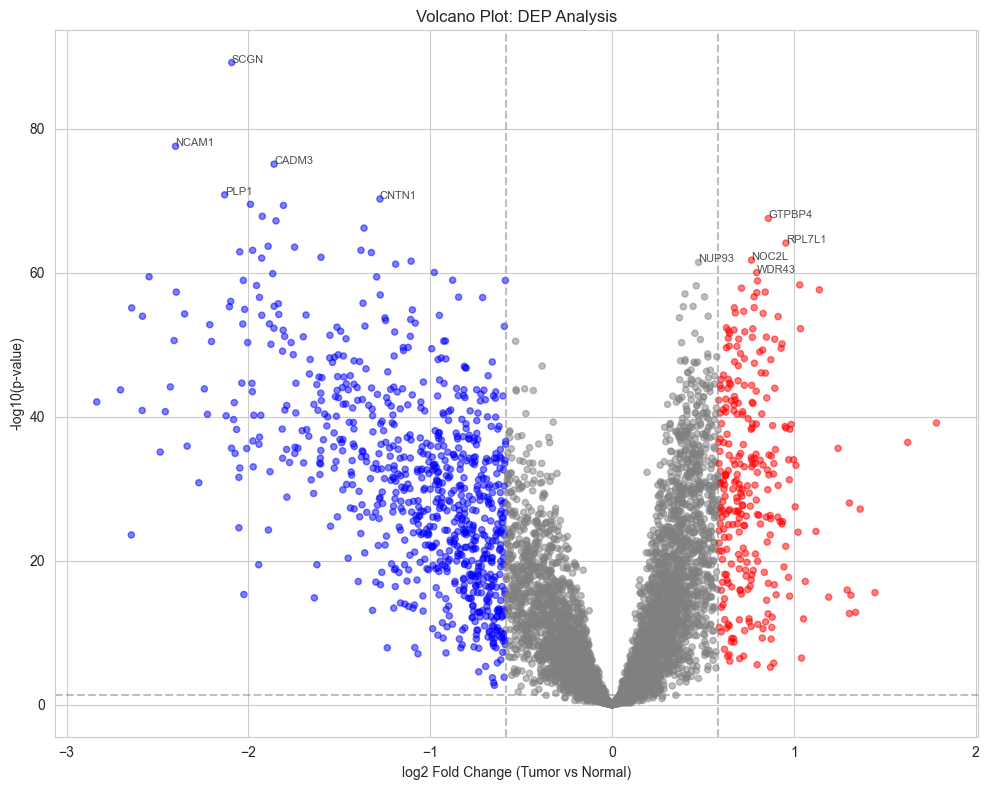

In [77]:
# Volcano plot

if dep_results is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Color classification
    colors = np.where(
        (dep_results['fdr'] < 0.05) & (dep_results['log2FC'] > np.log2(1.5)), 'red',
        np.where(
            (dep_results['fdr'] < 0.05) & (dep_results['log2FC'] < -np.log2(1.5)), 'blue',
            'gray'
        )
    )
    
    ax.scatter(dep_results['log2FC'], dep_results['-log10p'],
               c=colors, alpha=0.5, s=20)
    
    # Threshold lines
    ax.axhline(-np.log10(0.05), color='gray', linestyle='--', alpha=0.5)
    ax.axvline(np.log2(1.5), color='gray', linestyle='--', alpha=0.5)
    ax.axvline(-np.log2(1.5), color='gray', linestyle='--', alpha=0.5)
    
    # Label top genes
    top_up = dep_results[(dep_results['fdr']<0.05) & (dep_results['log2FC']>0)].head(5)
    top_down = dep_results[(dep_results['fdr']<0.05) & (dep_results['log2FC']<0)].head(5)
    for _, row in pd.concat([top_up, top_down]).iterrows():
        ax.annotate(row['protein'], (row['log2FC'], row['-log10p']),
                    fontsize=8, alpha=0.8)
    
    ax.set_xlabel('log2 Fold Change (Tumor vs Normal)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title('Volcano Plot: DEP Analysis')
    
    plt.tight_layout()
    plt.show()

---
## 6. Functional Enrichment Analysis

After identifying DEPs, this step determines which biological pathways are enriched.

### Methods:
- **ORA (Over-Representation Analysis)**: Tests whether specific pathways are over-represented in the DEP list (Fisher's exact test)
- **GSEA (Gene Set Enrichment Analysis)**: Ranks all proteins by fold change and tests whether pathway members cluster at the top or bottom
- **ssGSEA**: Calculates per-sample pathway activity scores (covered in detail in Notebook 2)

In [78]:
import gseapy as gp

# Method 1: ORA (based on DEP list)
if dep_results is not None:
    sig_proteins = dep_results[dep_results['fdr'] < 0.05]['protein'].tolist()
    print(f"Significant proteins for ORA: {len(sig_proteins)}")
    
    if len(sig_proteins) > 10:
        ora_results = gp.enrich(
            gene_list=sig_proteins,
            gene_sets='KEGG_2021_Human',
            outdir=None,
            no_plot=True
        )
        
        ora_df = ora_results.res2d.sort_values('Adjusted P-value').head(15)
        print("\nTop 15 enriched KEGG pathways:")
        print(ora_df[['Term', 'Adjusted P-value', 'Overlap']].to_string(index=False))
else:
    print("Skipping ORA (no DEP results)")

Significant proteins for ORA: 5659

Top 15 enriched KEGG pathways:
                                       Term  Adjusted P-value Overlap
                                Spliceosome      2.769121e-32 115/150
                                   Ribosome      1.527917e-31 118/158
                        Coronavirus disease      4.276482e-25 144/232
              Amyotrophic lateral sclerosis      4.276482e-25 200/364
                              Prion disease      1.553684e-23 159/273
                          Parkinson disease      3.366973e-23 148/249
                    Diabetic cardiomyopathy      3.902708e-22 126/203
                         Huntington disease      9.877451e-21 167/306
                              RNA transport      7.288497e-19 113/186
                                Endocytosis      7.317364e-18 139/252
              Pathways of neurodegeneration      6.042361e-17 223/475
                          Alzheimer disease      3.992754e-16 181/369
                       

In [79]:
# Method 2: GSEA (based on ranked list)
if dep_results is not None:
    # Rank by log2FC
    rank_data = dep_results.set_index('protein')['log2FC'].dropna().sort_values(ascending=False)
    
    gsea_results = gp.prerank(
        rnk=rank_data,
        gene_sets='MSigDB_Hallmark_2020',
        outdir=None,
        no_plot=True,
        min_size=10,
        max_size=500,
        seed=42
    )
    
    gsea_df = gsea_results.res2d.sort_values('FDR q-val')
    print("Top 15 GSEA Hallmark pathways:")
    print(gsea_df.head(15)[['Term', 'NES', 'FDR q-val']].to_string(index=False))
else:
    print("Skipping GSEA (no DEP results)")

Top 15 GSEA Hallmark pathways:
                             Term       NES FDR q-val
                   Myc Targets V1  3.322043       0.0
                      E2F Targets  3.169861       0.0
                   Myc Targets V2  3.157835       0.0
        Unfolded Protein Response  2.579143       0.0
                  G2-M Checkpoint  2.536976       0.0
                       Myogenesis -2.446111       0.0
                KRAS Signaling Dn -2.028317       0.0
                       DNA Repair  2.005064       0.0
                  Apical Junction -1.892184  0.000535
                 mTORC1 Signaling  1.914723  0.000738
Epithelial Mesenchymal Transition -1.847972  0.001004
              Pancreas Beta Cells -1.754019  0.003533
                  heme Metabolism  -1.72708  0.004283
                          Hypoxia -1.678996  0.007801
                      Coagulation -1.658156  0.009235


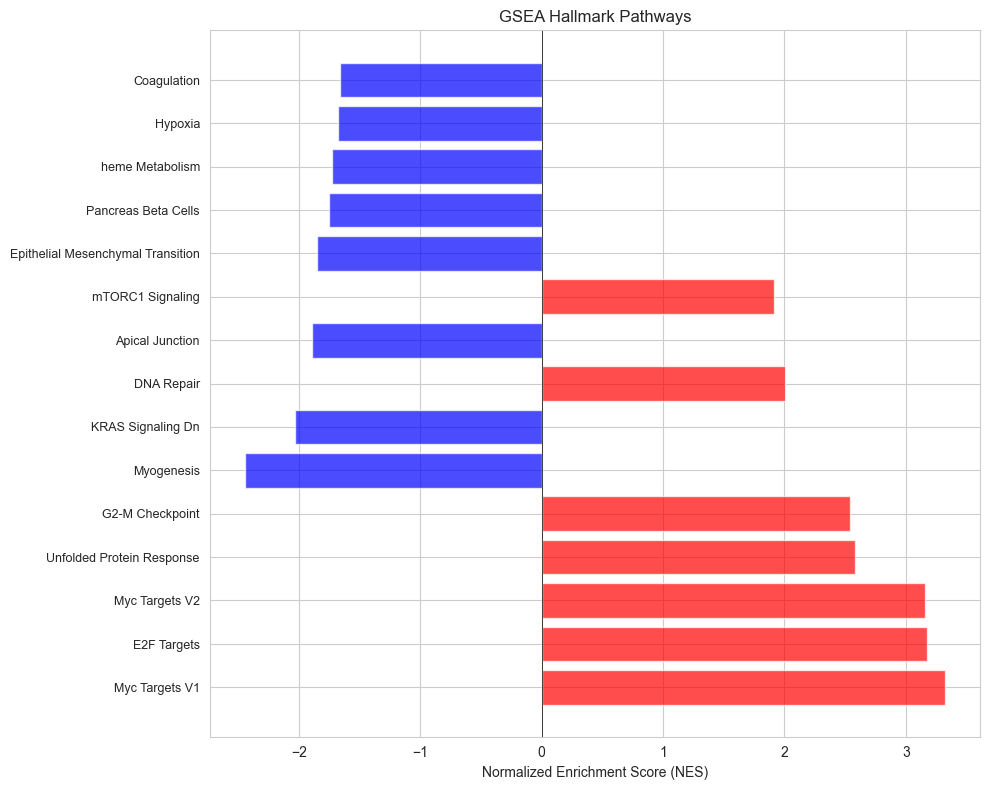

In [80]:
# Visualize enrichment results
if dep_results is not None and 'gsea_df' in dir():
    top_pathways = gsea_df.head(15).copy()
    top_pathways['NES'] = top_pathways['NES'].astype(float)
    top_pathways['-log10FDR'] = -np.log10(top_pathways['FDR q-val'].astype(float) + 1e-10)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['red' if x > 0 else 'blue' for x in top_pathways['NES']]
    ax.barh(range(len(top_pathways)), top_pathways['NES'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_pathways)))
    ax.set_yticklabels(top_pathways['Term'], fontsize=9)
    ax.set_xlabel('Normalized Enrichment Score (NES)')
    ax.set_title('GSEA Hallmark Pathways')
    ax.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

---
## 7. Unsupervised Clustering

Subgrouping samples based solely on proteomics data, without prior labels.

This step produces cluster assignments that can be used as molecular subtypes in downstream analyses.

Variance explained by 20 PCs: 61.8%


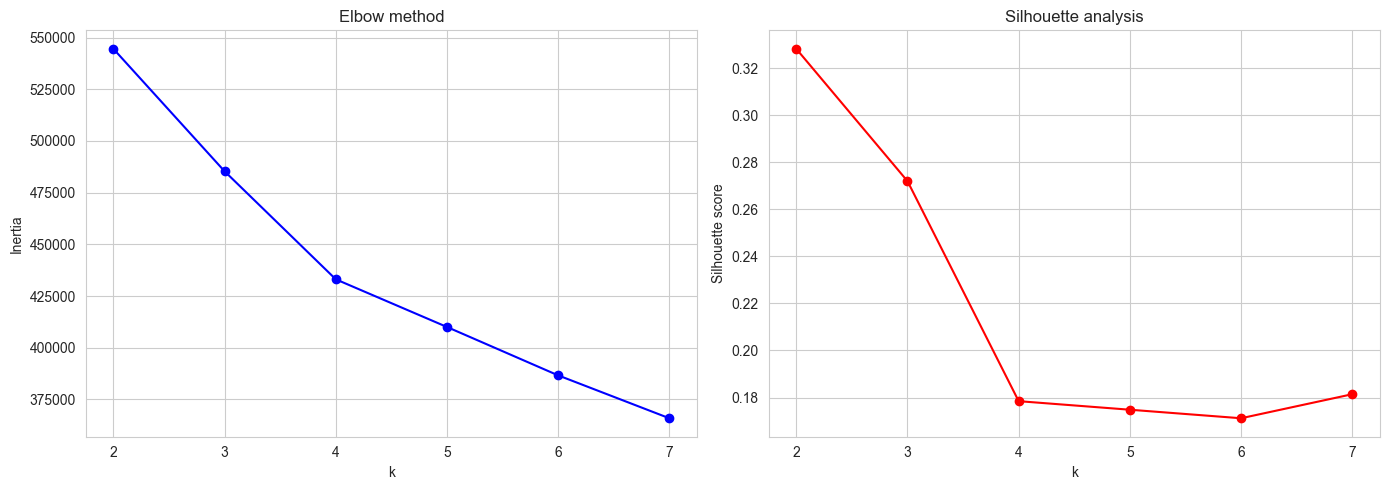

Best k by silhouette: 2


In [81]:
# Simplified consensus clustering: K-means + optimal k selection

# Standardize
scaler = StandardScaler()
prot_scaled = pd.DataFrame(
    scaler.fit_transform(prot_clean),
    index=prot_clean.index, columns=prot_clean.columns
)

# Dimensionality reduction via PCA (improves clustering stability)
pca_for_clust = PCA(n_components=20)
prot_pca = pca_for_clust.fit_transform(prot_scaled)
print(f"Variance explained by 20 PCs: {pca_for_clust.explained_variance_ratio_.sum():.1%}")

# Find optimal k using elbow method
inertias = []
sil_scores = []
K_range = range(2, 8)

from sklearn.metrics import silhouette_score

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(prot_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(prot_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette analysis')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"Best k by silhouette: {best_k}")

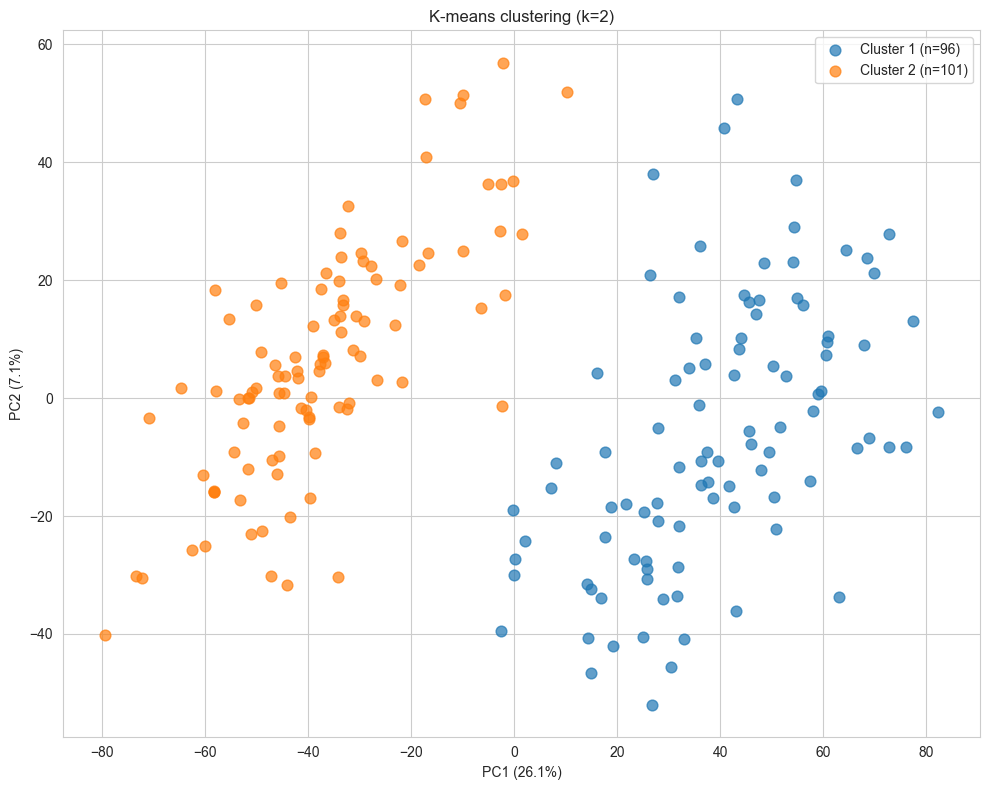

In [82]:
# Cluster with optimal k and visualize
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
cluster_labels = km_final.fit_predict(prot_pca)

# Show clusters on 2D PCA
pca_2d = PCA(n_components=2)
coords = pca_2d.fit_transform(prot_scaled)

plt.figure(figsize=(10, 8))
for c in range(best_k):
    mask = cluster_labels == c
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=f'Cluster {c+1} (n={mask.sum()})', alpha=0.7, s=60)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
plt.title(f'K-means clustering (k={best_k})')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
# Characterize clusters: association with clinical variables
cluster_series = pd.Series(cluster_labels, index=prot_clean.index, name='cluster')

# Merge with clinical data
common_idx = cluster_series.index.intersection(clinical.index)
merged = pd.DataFrame({
    'cluster': cluster_series.loc[common_idx]
}).join(clinical.loc[common_idx])

# Remove duplicate column names
merged = merged.loc[:, ~merged.columns.duplicated()]

print("=== Cluster vs Clinical features ===")
for col in merged.columns[:10]:
    if col == 'cluster':
        continue
    series = merged[col]
    if not isinstance(series, pd.Series):
        continue
    if series.dtype in ['float64', 'int64']:
        groups = [merged[merged['cluster']==c][col].dropna() for c in range(best_k)]
        if all(len(g) > 0 for g in groups):
            stat, p = stats.kruskal(*groups)
            print(f"  {col}: Kruskal-Wallis p={p:.4f}")
    else:
        ct = pd.crosstab(merged['cluster'], merged[col])
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            chi2, p, _, _ = stats.chi2_contingency(ct)
            print(f"  {col}: Chi-square p={p:.4f}")

=== Cluster vs Clinical features ===
  age: Chi-square p=0.9653
  sex: Chi-square p=1.0000
  race: Chi-square p=0.9849
  ethnicity: Chi-square p=0.9556


---
## 8. Multi-omics Integration Basics

Introduction to methods for integrating proteomics with other omics data types.

Common genes: 6609
Common samples: 96


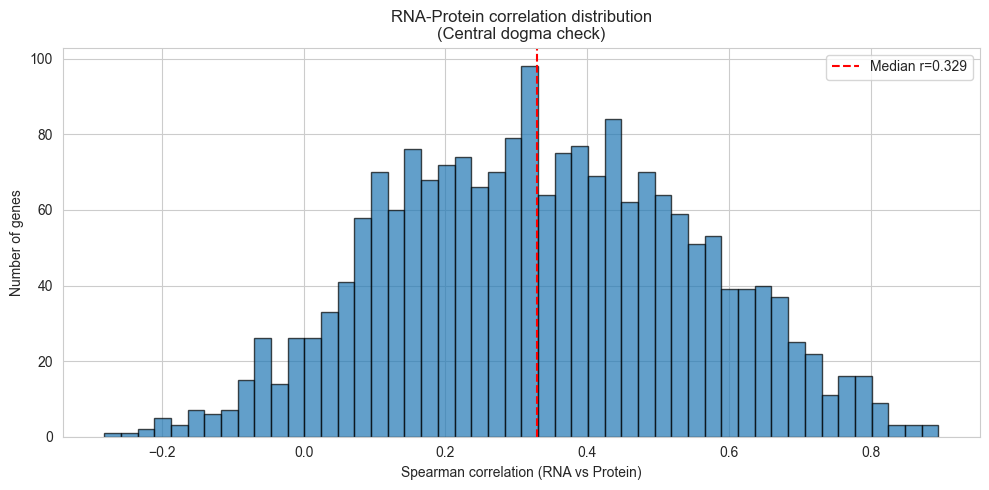

Median RNA-protein correlation: 0.329
Genes with r > 0.5: 475 (23.8%)
Genes with r < 0: 112 (5.6%)


In [84]:
# 8.1 Transcriptomics ↔ Proteomics correlation (RNA-protein correlation)
# Check how well the central dogma (DNA → RNA → Protein) holds in practice

try:
    transcriptomics = colon.get_transcriptomics(source="washu")
    
    # Handle MultiIndex
    if isinstance(transcriptomics.columns, pd.MultiIndex):
        trans = transcriptomics.copy()
        trans.columns = trans.columns.get_level_values(0)
        trans = trans.T.groupby(level=0).mean().T
    else:
        trans = transcriptomics.copy()
    
    # Common genes and samples
    common_genes = prot_clean.columns.intersection(trans.columns)
    common_samples = prot_clean.index.intersection(trans.index)
    print(f"Common genes: {len(common_genes)}")
    print(f"Common samples: {len(common_samples)}")
    
    # Per-gene RNA-protein correlation
    correlations = []
    for gene in common_genes[:2000]:  # First 2000 genes (for speed)
        p_vals = prot_clean.loc[common_samples, gene]
        t_vals = trans.loc[common_samples, gene]
        valid = p_vals.notna() & t_vals.notna()
        if valid.sum() > 10:
            r, p = stats.spearmanr(p_vals[valid], t_vals[valid])
            correlations.append({'gene': gene, 'spearman_r': r, 'p_value': p})
    
    corr_df = pd.DataFrame(correlations)
    
    plt.figure(figsize=(10, 5))
    plt.hist(corr_df['spearman_r'], bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(corr_df['spearman_r'].median(), color='red', linestyle='--',
                label=f'Median r={corr_df["spearman_r"].median():.3f}')
    plt.xlabel('Spearman correlation (RNA vs Protein)')
    plt.ylabel('Number of genes')
    plt.title('RNA-Protein correlation distribution\n(Central dogma check)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Median RNA-protein correlation: {corr_df['spearman_r'].median():.3f}")
    print(f"Genes with r > 0.5: {(corr_df['spearman_r'] > 0.5).sum()} ({(corr_df['spearman_r'] > 0.5).mean():.1%})")
    print(f"Genes with r < 0: {(corr_df['spearman_r'] < 0).sum()} ({(corr_df['spearman_r'] < 0).mean():.1%})")
    
except Exception as e:
    print(f"Transcriptomics not available: {e}")
    print("Transcriptomics data may not be available for all datasets.")

In [85]:
# 8.2 Mutation → Protein cis-effect (basics)
# Check whether mutations in a gene affect that protein's expression level

mutations = colon.get_somatic_mutation(source="washu")

def compare_mutation_protein(mutations_df, proteomics_df, gene):
    """Compare protein expression between mutated and wild-type samples for a given gene"""
    # Mutation status
    if 'Gene' in mutations_df.columns:
        gene_muts = mutations_df[mutations_df['Gene'] == gene]
        mutated_samples = set(gene_muts.index.get_level_values(0).unique())
    else:
        return None
    
    # Protein expression
    if isinstance(proteomics_df.columns, pd.MultiIndex):
        gene_cols = [c for c in proteomics_df.columns if c[0] == gene]
        if not gene_cols:
            return None
        prot_expr = proteomics_df[gene_cols].mean(axis=1)
    elif gene in proteomics_df.columns:
        prot_expr = proteomics_df[gene]
    else:
        return None
    
    # Group classification
    all_samples = prot_expr.dropna().index
    mut_group = prot_expr[[s for s in all_samples if s in mutated_samples]].dropna()
    wt_group = prot_expr[[s for s in all_samples if s not in mutated_samples]].dropna()
    
    if len(mut_group) < 3 or len(wt_group) < 3:
        return None
    
    stat, pval = stats.mannwhitneyu(mut_group, wt_group, alternative='two-sided')
    
    return {
        'gene': gene,
        'n_mutated': len(mut_group),
        'n_wildtype': len(wt_group),
        'median_mut': mut_group.median(),
        'median_wt': wt_group.median(),
        'diff': mut_group.median() - wt_group.median(),
        'p_value': pval,
        'mut_values': mut_group,
        'wt_values': wt_group
    }

# Run on major driver genes
test_genes = ['TP53', 'APC', 'KRAS', 'PIK3CA', 'SMAD4', 'BRAF']
cis_results = []

for gene in test_genes:
    result = compare_mutation_protein(mutations, proteomics, gene)
    if result:
        cis_results.append(result)
        print(f"{gene}: mut={result['n_mutated']}, wt={result['n_wildtype']}, "
              f"diff={result['diff']:.3f}, p={result['p_value']:.4f}")
    else:
        print(f"{gene}: insufficient data")

TP53: mut=39, wt=69, diff=0.364, p=0.0002
APC: insufficient data
KRAS: mut=37, wt=160, diff=-0.116, p=0.0430
PIK3CA: mut=22, wt=139, diff=-0.066, p=0.3613
SMAD4: mut=13, wt=184, diff=-0.271, p=0.0009
BRAF: mut=7, wt=56, diff=0.031, p=0.5699


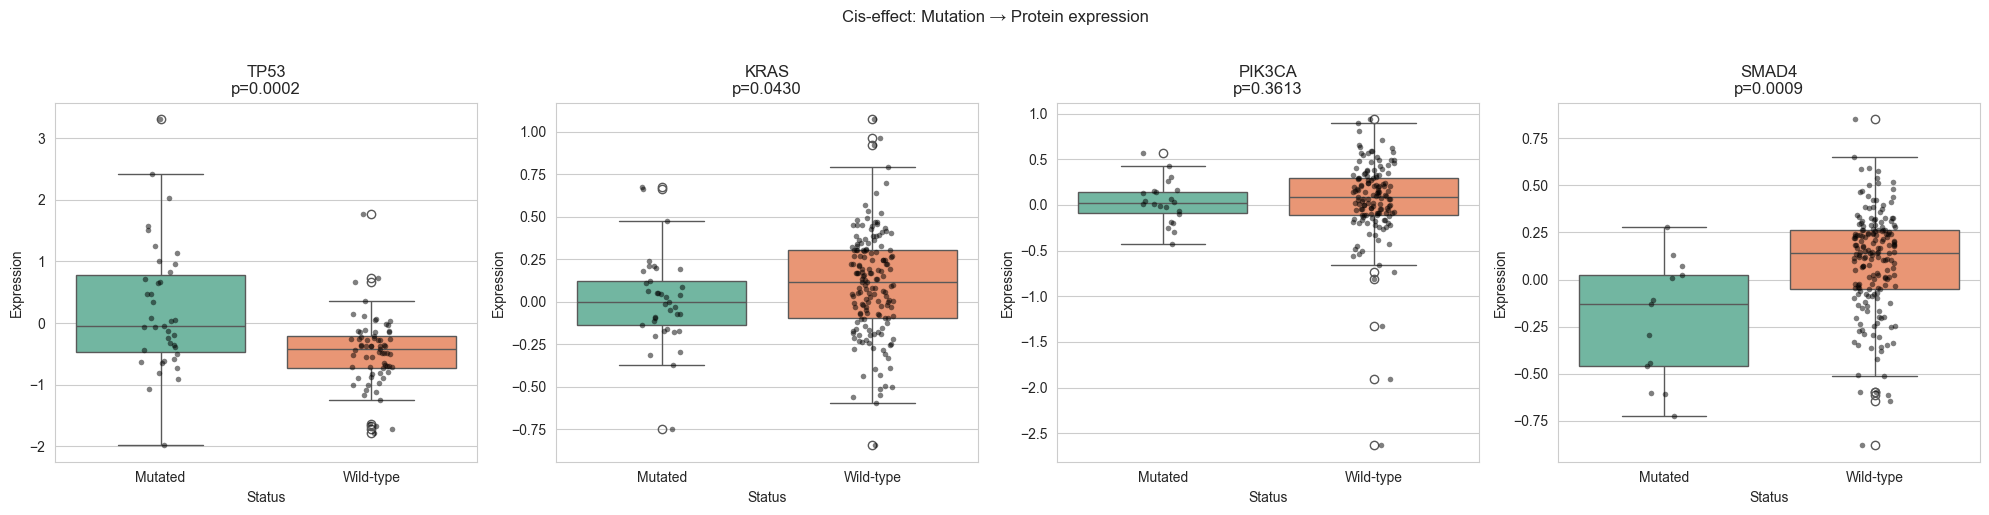

In [86]:
# Visualize cis-effects (most significant genes)
if cis_results:
    n_plots = min(len(cis_results), 4)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    
    for i, result in enumerate(cis_results[:n_plots]):
        data = pd.DataFrame({
            'Expression': pd.concat([result['mut_values'], result['wt_values']]),
            'Status': ['Mutated']*len(result['mut_values']) + ['Wild-type']*len(result['wt_values'])
        })
        sns.boxplot(data=data, x='Status', y='Expression', ax=axes[i], palette='Set2')
        sns.stripplot(data=data, x='Status', y='Expression', ax=axes[i],
                      color='black', alpha=0.5, size=4)
        axes[i].set_title(f"{result['gene']}\np={result['p_value']:.4f}")
    
    plt.suptitle('Cis-effect: Mutation → Protein expression', y=1.02)
    plt.tight_layout()
    plt.show()

---
## Summary: Bulk Proteomics Workflow Checklist

| Step | Purpose | Key tools | Done |
|------|---------|-----------|------|
| 1. Data loading | Understand structure, ID mapping | pandas, cptac | ☐ |
| 2. QC | Missing values, distribution, outliers | matplotlib, PCA | ☐ |
| 3. Imputation | Fill missing values | KNN, MinProb | ☐ |
| 4. Normalization check | Remove technical variation between samples | median centering, quantile | ☐ |
| 5. DEP | Differentially expressed proteins between groups | t-test, FDR correction | ☐ |
| 6. Enrichment | Pathway-level interpretation | gseapy (ORA, GSEA) | ☐ |
| 7. Clustering | Unsupervised subtyping | K-means, PCA | ☐ |
| 8. Multi-omics | Integration with other omics | RNA-prot corr, cis-effect | ☐ |

---

**Next steps**: Apply this workflow to your own proteomics dataset, and explore advanced analyses such as ssGSEA scoring, discordance analysis, and association with clinical outcomes.